< h1 > ACDC
LLaMA
8 - bit
Main
Demo < / h1 >

< p > This
notebook
shows
the
use
of
ACDC
on
the
Induction
task
using
LLaMA - 2 - 7
B in 8 - bit
quantization. < / p >


In [31]:
# 1. HuggingFace Login (ΑΠΑΡΑΙΤΗΤΟ ΓΙΑ LLaMA)
!pip
install - q
huggingface_hub
from huggingface_hub import login

# ΒΑΛΕ ΤΟ ΔΙΚΟ ΣΟΥ TOKEN ΕΔΩ! (Πρέπει να έχεις κάνει accept το license του LLaMA 2 στο HuggingFace)
login("hf_ΕΔΩ_ΤΟ_TOKEN_ΣΟΥ")


In [32]:
!rm - rf
ims /
try:
    import google.colab

    IN_COLAB = True
    print("Running as a Colab notebook")

    import subprocess  # to install graphviz dependencies

    command = ['apt-get', 'install', 'graphviz-dev']
    subprocess.run(command, check=True)

    import os  # make images folder

    os.mkdir("ims/")

    from IPython import get_ipython

    ipython = get_ipython()

    ipython.run_line_magic(  # install ACDC
        "pip",
        "install git+https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git@d89f7fa9cbd095202f3940c889cb7c6bf5a9b516",
    )

except Exception as e:
    IN_COLAB = False
    print("Running outside of colab")

    import numpy
    import plotly

    plotly.io.renderers.default = "colab"

    import os

    if not os.path.exists("ims/"):
        os.mkdir("ims/")

    from IPython import get_ipython

    ipython = get_ipython()
    if ipython is not None:
        print("Running as a notebook")
        ipython.run_line_magic("load_ext", "autoreload")
        ipython.run_line_magic("autoreload", "2")
    else:
        print("Running as a script")


Running as a Colab notebook
  Cloning https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git (to revision d89f7fa9cbd095202f3940c889cb7c6bf5a9b516) to /tmp/pip-req-build-3oxjhkqz
  Running command git clone --filter=blob:none --quiet https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git /tmp/pip-req-build-3oxjhkqz
  Running command git rev-parse -q --verify 'sha^d89f7fa9cbd095202f3940c889cb7c6bf5a9b516'
  Running command git fetch -q https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git d89f7fa9cbd095202f3940c889cb7c6bf5a9b516
  Running command git checkout -q d89f7fa9cbd095202f3940c889cb7c6bf5a9b516
  Resolved https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git to commit d89f7fa9cbd095202f3940c889cb7c6bf5a9b516
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/deepmind/tracr.git (to revision e75ecda) to /tmp/pip-install-ss4rlhta/tracr_e

In [33]:
# Download packages (Προσθήκη bitsandbytes & accelerate για 8-bit LLaMA)
!apt - get
install
graphviz - dev - y > / dev / null
!pip
install - q
transformer_lens
einops
kaleido
cmapy
torchtyping
wandb
pygraphviz
bitsandbytes
accelerate

# Download code in collab
!rm - rf
Automatic - Circuit - Discovery
!git
clone
https: // github.com / ArthurConmy / Automatic - Circuit - Discovery.git
%cd
Automatic - Circuit - Discovery
!git
checkout - q
d89f7fa9cbd095202f3940c889cb7c6bf5a9b516
%cd / content /


Cloning into 'Automatic-Circuit-Discovery'...
remote: Enumerating objects: 18990, done.
remote: Counting objects: 100% (1701/1701), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 18990 (delta 1556), reused 1454 (delta 1454), pack-reused 17289 (from 3)
Receiving objects: 100% (18990/18990), 114.39 MiB | 17.74 MiB/s, done.
Resolving deltas: 100% (13815/13815), done.
/content/Automatic-Circuit-Discovery
/content


< h2 > Imports and Fixes < / h2 >

In [34]:
import subprocess
import sys
import importlib
import os
import datetime
import time

# 2. Clear cache
import site

importlib.reload(site)
importlib.invalidate_caches()

# 3. THE ULTIMATE IN-MEMORY BYPASSES
import transformers

transformers.TRANSFORMERS_CACHE = "/tmp/hf_cache"

import transformer_lens

sys.modules['transformer_lens.HookedTransformerConfig'] = transformer_lens
sys.modules['transformer_lens.HookedTransformer'] = transformer_lens
sys.modules['transformer_lens.ActivationCache'] = transformer_lens
sys.modules['transformer_lens.FactoredMatrix'] = transformer_lens

import types

dummy_typeguard = types.ModuleType("typeguard")
dummy_typeguard.typechecked = lambda func: func
sys.modules["typeguard"] = dummy_typeguard


class DummyTensorType:
    def __getitem__(self, key):
        return self


dummy_torchtyping = types.ModuleType("torchtyping")
dummy_torchtyping.TensorType = DummyTensorType()
dummy_torchtyping.patch_typeguard = lambda *args, **kwargs: None
sys.modules["torchtyping"] = dummy_torchtyping

if '/content/Automatic-Circuit-Discovery' not in sys.path:
    sys.path.append('/content/Automatic-Circuit-Discovery')

import wandb
import IPython
from IPython.display import Image, display
import torch
import gc
from tqdm import tqdm
import networkx as nx
import huggingface_hub
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops

from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer

from transformer_lens.hook_points import HookedRootModule, HookPoint
from transformer_lens.HookedTransformer import HookedTransformer

from acdc.acdc_utils import (
    make_nd_dict,
    reset_network,
    shuffle_tensor,
    cleanup,
    ct,
    TorchIndex,
    Edge,
    EdgeType,
    kl_divergence,
    MatchNLLMetric,
    negative_log_probs
)

from acdc.TLACDCCorrespondence import TLACDCCorrespondence
from acdc.TLACDCInterpNode import TLACDCInterpNode
from acdc.TLACDCExperiment import TLACDCExperiment
from acdc.docstring.utils import AllDataThings

from acdc.induction.utils import (
    get_validation_data,
    get_good_induction_candidates,
    get_mask_repeat_candidates,
)
from acdc.acdc_graphics import show
import argparse

torch.autograd.set_grad_enabled(False)
print("\n Imports Success.")


Installing packages
Could not import `tracr` because No module named 'imp'; the rest of the file should work but you cannot use the tracr tasks

 Success.


< h2 > Setup
LLaMA - 2 - 7
B(8 - bit) and Task
Data < / h2 >

In [35]:

os.environ["TRANSFORMERS_USE_FAST"] = "True"


# --- ΑΝΤΙΚΑΤΑΣΤΑΣΗ ΤΗΣ get_model ΓΙΑ ΝΑ ΦΟΡΤΩΝΕΙ LLaMA 8-BIT ---
def get_model(device):
    model_name = "meta-llama/Llama-2-7b-hf"
    print(f"Loading {model_name} in 8-bit...")

    # Φόρτωση του μοντέλου σε 8-bit
    hf_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        load_in_8bit=True,
        device_map="auto"
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    # Το LLaMA χρειάζεται να του ορίσουμε pad_token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    tl_model = HookedTransformer.from_pretrained(
        model_name,
        hf_model=hf_model,
        tokenizer=tokenizer,
        center_writing_weights=False,
        center_unembed=False,
        fold_ln=False,
    )

    tl_model.set_use_attn_result(True)
    tl_model.set_use_split_qkv_input(True)
    return tl_model


# --- ΕΠΑΝΑΟΡΙΣΜΟΣ ΤΗΣ get_all_induction_things ΜΕΣΑ ΣΤΟ SCRIPT ---
def get_all_induction_things(num_examples, seq_len, device, data_seed=42, metric="kl_div",
                             return_one_element=True) -> AllDataThings:
    tl_model = get_model(device=device)

    validation_data_orig = get_validation_data(device=device)
    mask_orig = get_mask_repeat_candidates(num_examples=None, device=device)
    assert validation_data_orig.shape == mask_orig.shape
    assert seq_len <= validation_data_orig.shape[1] - 1

    validation_slice = slice(0, num_examples)
    validation_data = validation_data_orig[validation_slice, :seq_len].contiguous()
    validation_labels = validation_data_orig[validation_slice, 1:seq_len + 1].contiguous()
    validation_mask = mask_orig[validation_slice, :seq_len].contiguous()

    validation_patch_data = shuffle_tensor(validation_data, seed=data_seed).contiguous()

    test_slice = slice(num_examples, num_examples * 2)
    test_data = validation_data_orig[test_slice, :seq_len].contiguous()
    test_labels = validation_data_orig[test_slice, 1:seq_len + 1].contiguous()
    test_mask = mask_orig[test_slice, :seq_len].contiguous()

    test_patch_data = shuffle_tensor(test_data, seed=data_seed).contiguous()

    with torch.no_grad():
        base_val_logprobs = F.log_softmax(tl_model(validation_data), dim=-1).detach()
        base_test_logprobs = F.log_softmax(tl_model(test_data), dim=-1).detach()

    validation_metric = partial(
        kl_divergence,
        base_model_logprobs=base_val_logprobs,
        mask_repeat_candidates=validation_mask,
        last_seq_element_only=False,
        return_one_element=return_one_element,
    )

    test_metrics = {
        "kl_div": partial(
            kl_divergence,
            base_model_logprobs=base_test_logprobs,
            mask_repeat_candidates=test_mask,
            last_seq_element_only=False,
        ),
    }

    return AllDataThings(
        tl_model=tl_model,
        validation_metric=validation_metric,
        validation_data=validation_data,
        validation_labels=validation_labels,
        validation_mask=validation_mask,
        validation_patch_data=validation_patch_data,
        test_metrics=test_metrics,
        test_data=test_data,
        test_labels=test_labels,
        test_mask=test_mask,
        test_patch_data=test_patch_data,
    )


# --- Configuration & Arguments ---
class DummyArgs:
    pass


args = DummyArgs()
args.task = "induction"
args.threshold = 1.0  # ΑΥΞΗΜΕΝΟ THRESHOLD ΓΙΑ ΓΡΗΓΟΡΟΤΕΡΟ PRUNING ΣΤΟ LLAMA
args.zero_ablation = False
args.indices_mode = "reverse"
args.names_mode = "normal"
args.device = "cuda"
args.metric = "kl_div"
args.seed = 1234
args.max_num_epochs = 100000
args.single_step = True  # ΤΟ ΒΑΛΑΜΕ TRUE ΓΙΑ ΝΑ ΚΑΝΕΙ ΕΝΑ ΒΗΜΑ ΜΟΝΟ ΚΑΙ ΝΑ ΜΗΝ ΚΟΛΛΗΣΕΙ
args.abs_value_threshold = False
args.wandb_dir = "/tmp/wandb"
args.wandb_mode = "online"

ONLINE_CACHE_CPU = False
CORRUPTED_CACHE_CPU = False
THRESHOLD = args.threshold
ZERO_ABLATION = args.zero_ablation
USING_WANDB = False  # Κλειστό το Wandb για απλότητα
INDICES_MODE = args.indices_mode
NAMES_MODE = args.names_mode
DEVICE = args.device
RESET_NETWORK = False
SINGLE_STEP = args.single_step

torch.manual_seed(args.seed)

print(f"Task: {args.task} with threshold: {THRESHOLD}...")

# Μειώνουμε πολύ τα examples και το length για να αντέξει η RAM/VRAM με το LLaMA
num_examples = 2
seq_len = 50

things = get_all_induction_things(
    num_examples=num_examples, seq_len=seq_len, device=DEVICE, metric=args.metric
)

print("\nData Success!")


Task: induction with threshold: 0.5623...
Loaded pretrained model redwood_attn_2l into HookedTransformer

Success!


< h2 > Setup
ACDC
Experiment < / h2 >

In [36]:

validation_metric = things.validation_metric
toks_int_values = things.validation_data
toks_int_values_other = things.validation_patch_data
tl_model = things.tl_model

tl_model.reset_hooks()
gc.collect()
torch.cuda.empty_cache()

WANDB_RUN_NAME = "llama_induction_test"
notes = "Testing LLaMA 8-bit ACDC"

exp = TLACDCExperiment(
    model=tl_model,
    threshold=THRESHOLD,
    using_wandb=USING_WANDB,
    wandb_entity_name="test",
    wandb_project_name="acdc",
    wandb_run_name=WANDB_RUN_NAME,
    wandb_group_name="default",
    wandb_notes=notes,
    wandb_dir=args.wandb_dir,
    wandb_mode=args.wandb_mode,
    wandb_config=args,
    zero_ablation=ZERO_ABLATION,
    abs_value_threshold=args.abs_value_threshold,
    ds=toks_int_values,
    ref_ds=toks_int_values_other,
    metric=validation_metric,
    second_metric=None,
    verbose=True,
    indices_mode=INDICES_MODE,
    names_mode=NAMES_MODE,
    corrupted_cache_cpu=CORRUPTED_CACHE_CPU,
    hook_verbose=False,
    online_cache_cpu=ONLINE_CACHE_CPU,
    add_sender_hooks=True,
    use_pos_embed=False,
    add_receiver_hooks=False,
    remove_redundant=False,
    show_full_index=False,
)


< h2 > View
Prompts and Induction
Targets < / h2 >

In [37]:

val_data = things.validation_data
mask = things.validation_mask

for prompt_idx in range(len(val_data)):
    prompt_tokens = val_data[prompt_idx]
    prompt_text = tl_model.to_string(prompt_tokens)

    print("\n" + "=" * 60)
    print(f"--- Real Text (Prompt {prompt_idx}) ---")
    print(prompt_text)

    print(f"\n--- Induction Targets (Mask) for Prompt {prompt_idx} ---")

    induction_count = 0
    for i, (token_id, is_induction_target) in enumerate(zip(prompt_tokens, mask[prompt_idx])):
        if is_induction_target:
            print(f"Position {i}: The model was expected to predict token '{tl_model.to_string(token_id)}'")
            induction_count += 1

    if induction_count == 0:
        print("No repeating induction patterns were found in this prompt.")


dict_keys(['blocks.1.hook_resid_post', 'blocks.1.attn.hook_result', 'blocks.1.attn.hook_q', 'blocks.1.hook_q_input', 'blocks.1.attn.hook_k', 'blocks.1.hook_k_input', 'blocks.1.attn.hook_v', 'blocks.1.hook_v_input', 'blocks.0.attn.hook_result', 'blocks.0.attn.hook_q', 'blocks.0.hook_q_input', 'blocks.0.attn.hook_k', 'blocks.0.hook_k_input', 'blocks.0.attn.hook_v', 'blocks.0.hook_v_input', 'blocks.0.hook_resid_pre'])
ln_final.hook_normalized
ln_final.hook_scale
blocks.1.hook_resid_post
blocks.1.hook_attn_out
blocks.1.attn.hook_result
blocks.1.attn.hook_z
blocks.1.attn.hook_pattern
blocks.1.attn.hook_attn_scores
blocks.1.attn.hook_v
blocks.1.attn.hook_k
blocks.1.attn.hook_q
blocks.1.ln1.hook_normalized
blocks.1.ln1.hook_scale
blocks.1.hook_v_input
blocks.1.hook_k_input
blocks.1.hook_q_input
blocks.1.hook_resid_pre
blocks.0.hook_resid_post
blocks.0.hook_attn_out
blocks.0.attn.hook_result
blocks.0.attn.hook_z
blocks.0.attn.hook_pattern
blocks.0.attn.hook_attn_scores
blocks.0.attn.hook_v
blo

< h2 > Run
steps
of
ACDC < / h2 >

In [25]:

exp_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
last_edge_count = exp.count_no_edges()

for i in range(args.max_num_epochs):
    print(f"\n--- Starting Step {i + 1} ---")
    exp.step(testing=False)

    current_edge_count = exp.count_no_edges()

    if current_edge_count < last_edge_count:
        print(f"Edge removed! New set: {current_edge_count}")
        fname = f"ims/img_pruned_{i + 1}.png"

        # Λόγω τεράστιου μεγέθους LLaMA, ίσως η ζωγραφιά του γράφου να κρασάρει,
        # Οπότε το βάζουμε σε try/except block
        try:
            show(exp.corr, fname=fname, show_full_index=False)
            if IN_COLAB or ipython is not None:
                display(Image(fname))
        except Exception as e:
            print(f"Could not render graph (too large?): {e}")

        last_edge_count = current_edge_count

    print(i, "-" * 50)
    print(f"Edges remaining: {current_edge_count}")

    if i == 0:
        exp.save_edges("edges.pkl")

    if exp.current_node is None or SINGLE_STEP:
        print("\nStopping ACDC loop (Single Step is True or Graph Finished).")
        try:
            show(exp.corr, f"ims/ACDC_img_{exp_time}.png")
        except:
            pass
        break

HookedTransformerConfig:
{'act_fn': 'gelu_new',
 'attention_dir': 'causal',
 'attn_only': True,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 32,
 'd_mlp': -1,
 'd_model': 256,
 'd_vocab': 50259,
 'd_vocab_out': 50259,
 'default_prepend_bos': True,
 'device': 'cuda',
 'dtype': torch.float32,
 'eps': 1e-05,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': False,
 'initializer_range': np.float64(0.05),
 'model_name': 'redwood_attn_2l',
 'n_ctx': 2048,
 'n_devices': 1,
 'n_heads': 8,
 'n_layers': 2,
 'n_params': 524288,
 'normalization_type': 'LN',
 'original_architecture': 'neel',
 'parallel_attn_mlp': False,
 'positional_embedding_type': 'shortformer',
 'rotary_dim': None,
 'scale_attn_by_inverse_layer_idx': False,
 'seed': None,
 'tokenizer_name': 'ArthurConmy/redwood_tokenizer',
 'use_attn_result': True,
 'use_attn_scale': True,
 'use_hook_mlp_in': True,
 

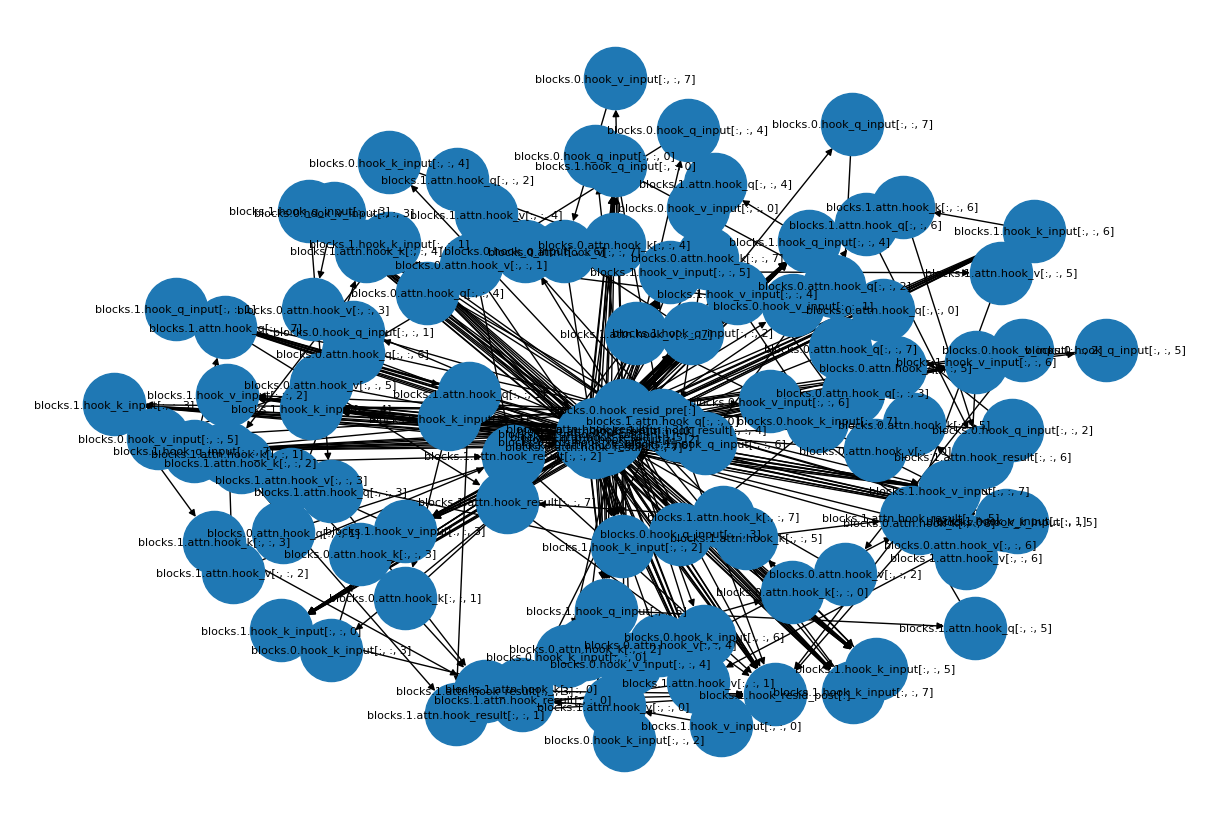

In [27]:
import networkx as nx

G = nx.DiGraph()

for (receiver_name, receiver_index, sender_name, sender_index), edge in exp.corr.all_edges().items():
    if not edge.present:
        continue

    src = f"{sender_name}{sender_index}"
    dst = f"{receiver_name}{receiver_index}"

    G.add_edge(src, dst)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=8,
    arrows=True
)

plt.show()

No edge 305
No edge 305
New metric: 0.0

Node: cur_parent=TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.1.hook_resid_post, [:]))

Metric after removing connection to blocks.1.attn.hook_result [:, :, 0] is 0.02825758419930935 (and current metric 0.0)
Result is 0.02825758419930935...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 1]) (self.current_node=TLACDCInterpNode(blocks.1.hook_resid_post, [:]))

Metric after removing connection to blocks.1.attn.hook_result [:, :, 1] is 0.03580968827009201 (and current metric 0.02825758419930935)
Result is 0.0075521040707826614...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 2]) (self.current_node=TLACDCInterpNode(blocks.1.hook_resid_post, [:]))

Metric after removing connection to blocks.1.attn.hook_result [:, :, 2] is 0.04275461286306381 (and current metric 0.03580968827009201)
Result is 0.006944924592971802

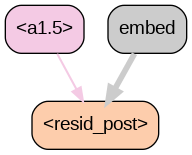

0 --------------------------------------------------
Edges remaining: 290
No edge 290
New metric: 2.7369933128356934
No edge 290
No edge 290
No edge 290
We moved to  blocks.1.attn.hook_result[:, :, 4]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 3]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 2]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 1]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 0]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 7]
No edge 290
No edge 289
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 6]
No edge 289
No edge 288
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 5]
No edge 288
No edge 288
Edge removed! New set: 288


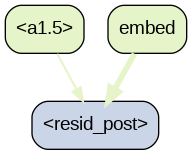

1 --------------------------------------------------
Edges remaining: 288
No edge 288
New metric: 2.7369933128356934

Node: cur_parent=TLACDCInterpNode(blocks.1.hook_v_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 5]))

Metric after removing connection to blocks.1.hook_v_input [:, :, 5] is 8.177030563354492 (and current metric 2.7369933128356934)
Result is 5.440037250518799...so keeping connection
No edge 288
We moved to  blocks.1.attn.hook_v[:, :, 4]
No edge 288
No edge 287
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 3]
No edge 287
No edge 286
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 2]
No edge 286
No edge 285
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 1]
No edge 285
No edge 284
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 0]
No edge 284
No edge 283
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 7]
No edge 283
No edge 282
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 6]
No edge 282
No edge 281
But

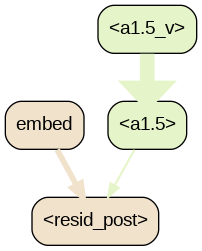

2 --------------------------------------------------
Edges remaining: 281
No edge 281
New metric: 2.7369933128356934

Node: cur_parent=TLACDCInterpNode(blocks.1.hook_k_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.1.attn.hook_k, [:, :, 5]))

Metric after removing connection to blocks.1.hook_k_input [:, :, 5] is 7.835738658905029 (and current metric 2.7369933128356934)
Result is 5.098745346069336...so keeping connection
No edge 281
We moved to  blocks.1.attn.hook_k[:, :, 4]
No edge 281
No edge 280
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 3]
No edge 280
No edge 279
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 2]
No edge 279
No edge 278
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 1]
No edge 278
No edge 277
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 0]
No edge 277
No edge 276
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 7]
No edge 276
No edge 275
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 6]
No edge 275
No edge 274
But

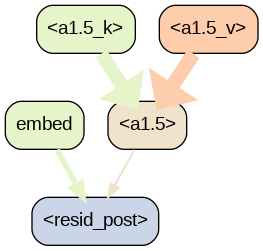

3 --------------------------------------------------
Edges remaining: 274
No edge 274
New metric: 2.7369933128356934

Node: cur_parent=TLACDCInterpNode(blocks.1.hook_q_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.1.attn.hook_q, [:, :, 5]))

Metric after removing connection to blocks.1.hook_q_input [:, :, 5] is 7.583526134490967 (and current metric 2.7369933128356934)
Result is 4.846532821655273...so keeping connection
No edge 274
We moved to  blocks.1.attn.hook_q[:, :, 4]
No edge 274
No edge 273
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 3]
No edge 273
No edge 272
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 2]
No edge 272
No edge 271
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 1]
No edge 271
No edge 270
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 0]
No edge 270
No edge 269
But it's bad
We moved to  blocks.1.hook_v_input[:, :, 7]
No edge 269
No edge 260
But it's bad
We moved to  blocks.1.hook_v_input[:, :, 6]
No edge 260
No edge 251
B

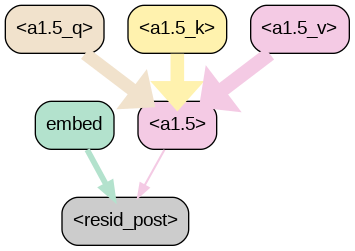

4 --------------------------------------------------
Edges remaining: 251
No edge 251
New metric: 2.7369933128356934

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.1.hook_v_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 0] is 2.5748038291931152 (and current metric 2.7369933128356934)
Result is -0.16218948364257812...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 1]) (self.current_node=TLACDCInterpNode(blocks.1.hook_v_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 1] is 3.0143392086029053 (and current metric 2.5748038291931152)
Result is 0.43953537940979004...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 2]) (self.current_node=TLACDCInterpNode(blocks.1.hook_v_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 

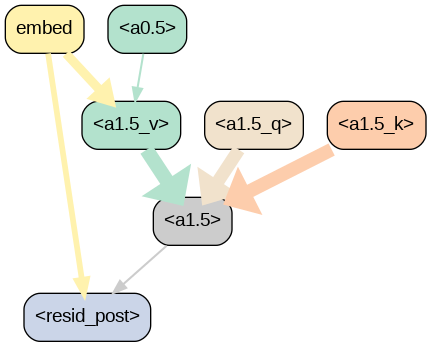

5 --------------------------------------------------
Edges remaining: 181
No edge 181
New metric: 3.6091716289520264

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.1.hook_k_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 0] is 6.714070796966553 (and current metric 3.6091716289520264)
Result is 3.1048991680145264...so keeping connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 1]) (self.current_node=TLACDCInterpNode(blocks.1.hook_k_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 1] is 3.576704502105713 (and current metric 3.6091716289520264)
Result is -0.03246712684631348...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 2]) (self.current_node=TLACDCInterpNode(blocks.1.hook_k_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 2] i

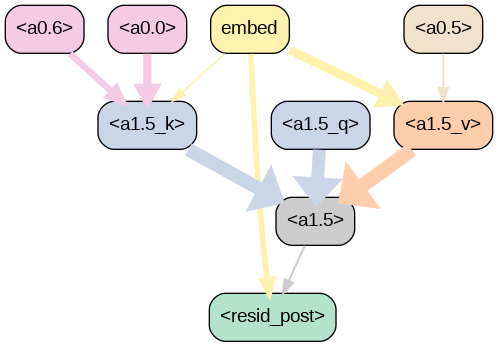

6 --------------------------------------------------
Edges remaining: 112
No edge 112
New metric: 4.007043838500977

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.1.hook_q_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 0] is 4.134673118591309 (and current metric 4.007043838500977)
Result is 0.12762928009033203...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 1]) (self.current_node=TLACDCInterpNode(blocks.1.hook_q_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 1] is 4.476898670196533 (and current metric 4.134673118591309)
Result is 0.3422255516052246...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 2]) (self.current_node=TLACDCInterpNode(blocks.1.hook_q_input, [:, :, 5]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 2] is 4

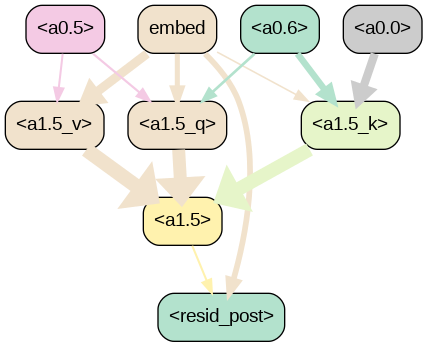

7 --------------------------------------------------
Edges remaining: 61
No edge 61
New metric: 5.539362907409668
No edge 61
No edge 61
No edge 61
We moved to  blocks.0.attn.hook_result[:, :, 5]
No edge 61
No edge 61
8 --------------------------------------------------
Edges remaining: 61
No edge 61
New metric: 5.539362907409668
No edge 61
No edge 61
No edge 61
We moved to  blocks.0.attn.hook_result[:, :, 4]
No edge 61
No edge 61
But it's bad
We moved to  blocks.0.attn.hook_result[:, :, 3]
No edge 61
No edge 61
But it's bad
We moved to  blocks.0.attn.hook_result[:, :, 2]
No edge 61
No edge 61
But it's bad
We moved to  blocks.0.attn.hook_result[:, :, 1]
No edge 61
No edge 61
But it's bad
We moved to  blocks.0.attn.hook_result[:, :, 0]
No edge 61
No edge 61
9 --------------------------------------------------
Edges remaining: 61
No edge 61
New metric: 5.539362907409668
No edge 61
No edge 61
No edge 61
We moved to  blocks.0.attn.hook_v[:, :, 7]
No edge 61
No edge 60
But it's bad
We moved 

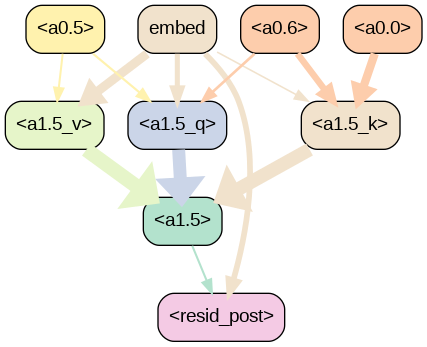

10 --------------------------------------------------
Edges remaining: 60
No edge 60
New metric: 5.539362907409668

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_v, [:, :, 6]))

Metric after removing connection to blocks.0.hook_v_input [:, :, 6] is 6.696844577789307 (and current metric 5.539362907409668)
Result is 1.1574816703796387...so keeping connection
No edge 60
We moved to  blocks.0.attn.hook_v[:, :, 5]
No edge 60
No edge 60
11 --------------------------------------------------
Edges remaining: 60
No edge 60
New metric: 5.539362907409668

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_v, [:, :, 5]))

Metric after removing connection to blocks.0.hook_v_input [:, :, 5] is 6.656718730926514 (and current metric 5.539362907409668)
Result is 1.1173558235168457...so keeping connection
No edge 60
We moved to  blocks.0.attn.hook_v[:, :, 4

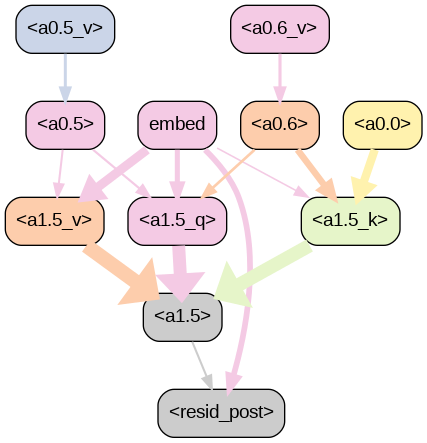

12 --------------------------------------------------
Edges remaining: 56
No edge 56
New metric: 5.539362907409668

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_v, [:, :, 0]))

Metric after removing connection to blocks.0.hook_v_input [:, :, 0] is 7.499373912811279 (and current metric 5.539362907409668)
Result is 1.9600110054016113...so keeping connection
No edge 56
We moved to  blocks.0.attn.hook_k[:, :, 7]
No edge 56
No edge 55
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 6]
No edge 55
No edge 55
Edge removed! New set: 55


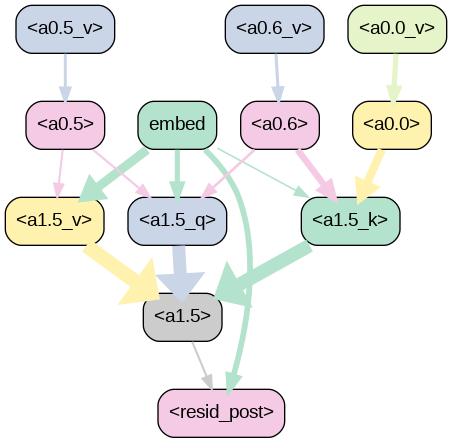

13 --------------------------------------------------
Edges remaining: 55
No edge 55
New metric: 5.539362907409668

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_k_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_k, [:, :, 6]))

Metric after removing connection to blocks.0.hook_k_input [:, :, 6] is 5.741295337677002 (and current metric 5.539362907409668)
Result is 0.20193243026733398...so removing connection
No edge 54
We moved to  blocks.0.attn.hook_k[:, :, 5]
No edge 54
No edge 54
Edge removed! New set: 54


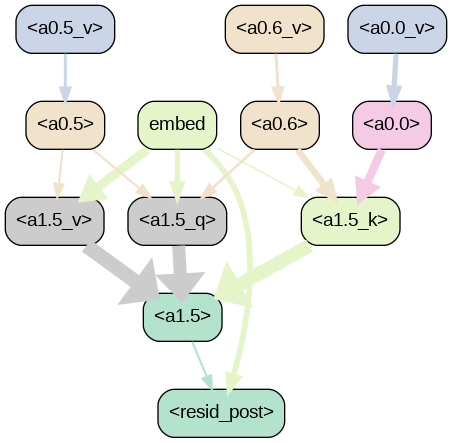

14 --------------------------------------------------
Edges remaining: 54
No edge 54
New metric: 5.741295337677002

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_k_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_k, [:, :, 5]))

Metric after removing connection to blocks.0.hook_k_input [:, :, 5] is 6.701699256896973 (and current metric 5.741295337677002)
Result is 0.9604039192199707...so keeping connection
No edge 54
We moved to  blocks.0.attn.hook_k[:, :, 4]
No edge 54
No edge 53
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 3]
No edge 53
No edge 52
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 2]
No edge 52
No edge 51
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 1]
No edge 51
No edge 50
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 0]
No edge 50
No edge 50
Edge removed! New set: 50


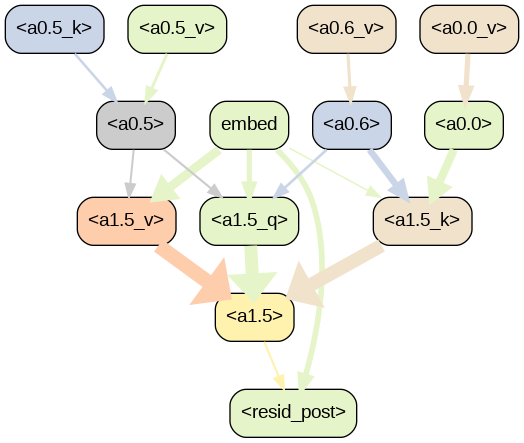

15 --------------------------------------------------
Edges remaining: 50
No edge 50
New metric: 5.741295337677002

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_k_input, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_k, [:, :, 0]))

Metric after removing connection to blocks.0.hook_k_input [:, :, 0] is 5.791281700134277 (and current metric 5.741295337677002)
Result is 0.04998636245727539...so removing connection
No edge 49
We moved to  blocks.0.attn.hook_q[:, :, 7]
No edge 49
No edge 48
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 6]
No edge 48
No edge 48
Edge removed! New set: 48


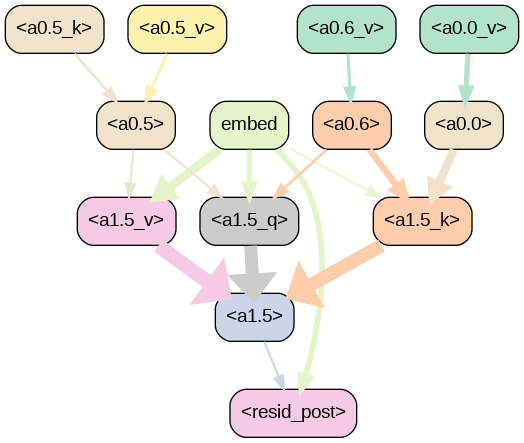

16 --------------------------------------------------
Edges remaining: 48
No edge 48
New metric: 5.791281700134277

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_q_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_q, [:, :, 6]))

Metric after removing connection to blocks.0.hook_q_input [:, :, 6] is 5.840714931488037 (and current metric 5.791281700134277)
Result is 0.049433231353759766...so removing connection
No edge 47
We moved to  blocks.0.attn.hook_q[:, :, 5]
No edge 47
No edge 47
Edge removed! New set: 47


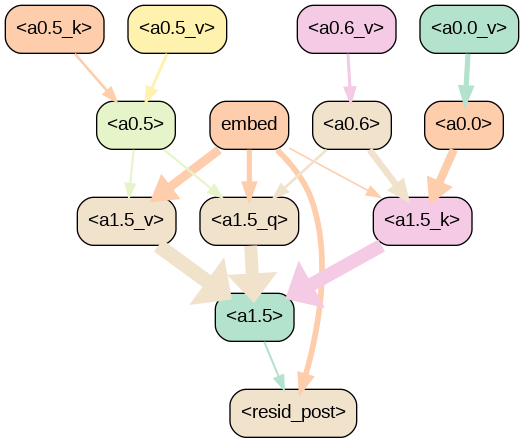

17 --------------------------------------------------
Edges remaining: 47
No edge 47
New metric: 5.840714931488037

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_q_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_q, [:, :, 5]))

Metric after removing connection to blocks.0.hook_q_input [:, :, 5] is 6.842995643615723 (and current metric 5.840714931488037)
Result is 1.0022807121276855...so keeping connection
No edge 47
We moved to  blocks.0.attn.hook_q[:, :, 4]
No edge 47
No edge 46
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 3]
No edge 46
No edge 45
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 2]
No edge 45
No edge 44
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 1]
No edge 44
No edge 43
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 0]
No edge 43
No edge 43
Edge removed! New set: 43


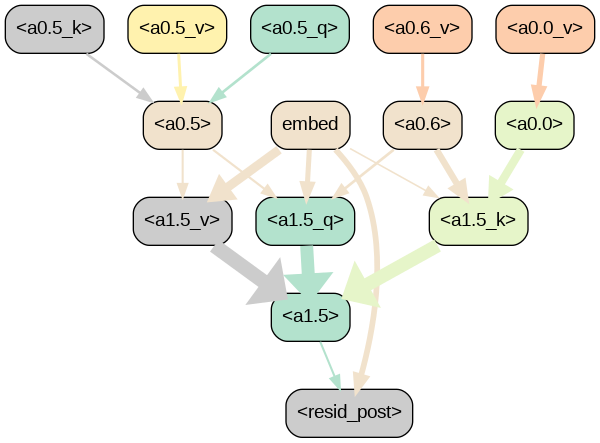

18 --------------------------------------------------
Edges remaining: 43
No edge 43
New metric: 5.840714931488037

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_q_input, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_q, [:, :, 0]))

Metric after removing connection to blocks.0.hook_q_input [:, :, 0] is 5.938253402709961 (and current metric 5.840714931488037)
Result is 0.09753847122192383...so removing connection
No edge 42
We moved to  blocks.0.hook_v_input[:, :, 7]
No edge 42
No edge 41
But it's bad
We moved to  blocks.0.hook_v_input[:, :, 6]
No edge 41
No edge 41
Edge removed! New set: 41


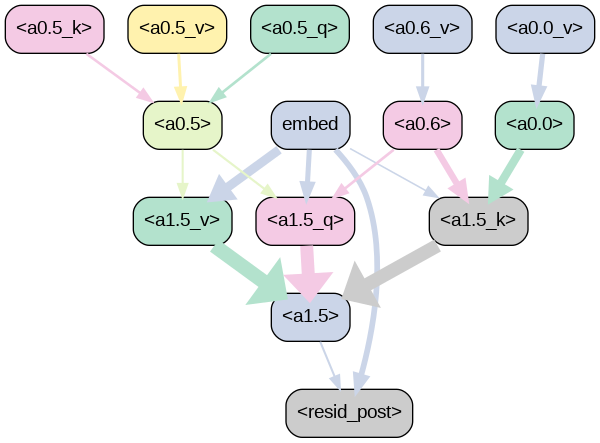

19 --------------------------------------------------
Edges remaining: 41
No edge 41
New metric: 5.938253402709961

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 6]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 6.819479942321777 (and current metric 5.938253402709961)
Result is 0.8812265396118164...so keeping connection
No edge 41
We moved to  blocks.0.hook_v_input[:, :, 5]
No edge 41
No edge 41
20 --------------------------------------------------
Edges remaining: 41
No edge 41
New metric: 5.9382524490356445

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 5]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 6.952104091644287 (and current metric 5.9382524490356445)
Result is 1.0138516426086426...so keeping connection
No edge 41
We moved to  blocks.0.hook_v_input[:, :, 4]
No edge 

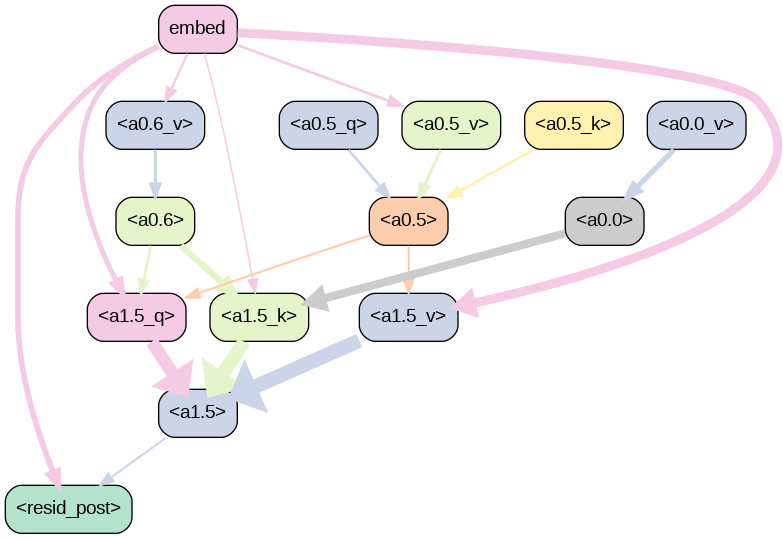

21 --------------------------------------------------
Edges remaining: 37
No edge 37
New metric: 5.9382524490356445

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 0]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 7.615676403045654 (and current metric 5.9382524490356445)
Result is 1.6774239540100098...so keeping connection
No edge 37
We moved to  blocks.0.hook_k_input[:, :, 7]
No edge 37
No edge 36
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 6]
No edge 36
No edge 35
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 5]
No edge 35
No edge 35
Edge removed! New set: 35


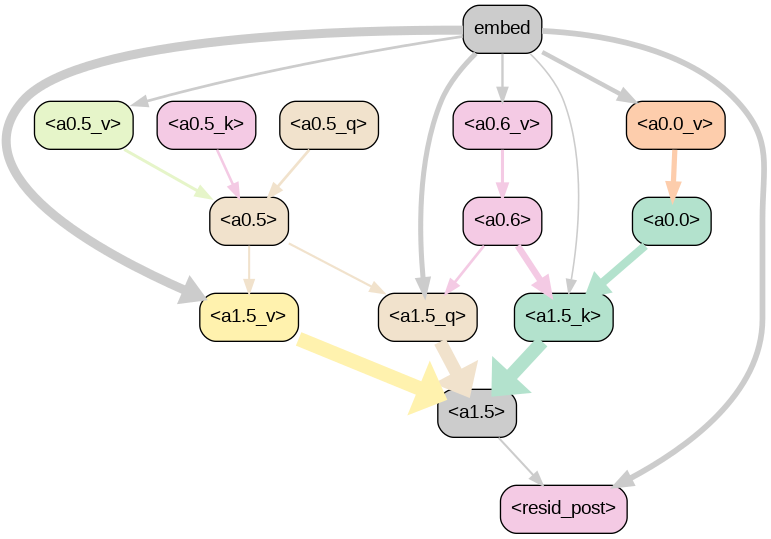

22 --------------------------------------------------
Edges remaining: 35
No edge 35
New metric: 5.9382524490356445

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_k_input, [:, :, 5]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 6.804245471954346 (and current metric 5.9382524490356445)
Result is 0.8659930229187012...so keeping connection
No edge 35
We moved to  blocks.0.hook_k_input[:, :, 4]
No edge 35
No edge 34
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 3]
No edge 34
No edge 33
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 2]
No edge 33
No edge 32
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 1]
No edge 32
No edge 31
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 0]
No edge 31
No edge 30
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 7]
No edge 30
No edge 29
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 6]
No edge 29
No edge 28
But it's bad
We mo

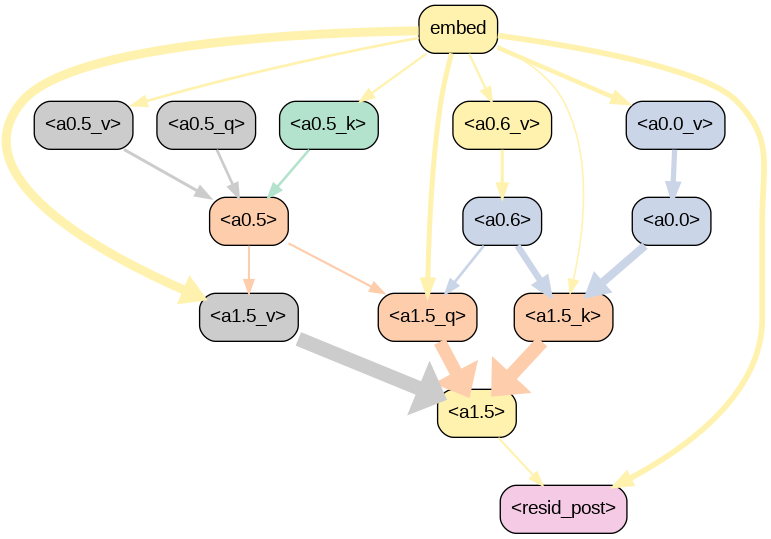

23 --------------------------------------------------
Edges remaining: 28
No edge 28
New metric: 5.9382524490356445

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_q_input, [:, :, 5]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 6.879561901092529 (and current metric 5.9382524490356445)
Result is 0.9413094520568848...so keeping connection
No edge 28
We moved to  blocks.0.hook_q_input[:, :, 4]
No edge 28
No edge 27
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 3]
No edge 27
No edge 26
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 2]
No edge 26
No edge 25
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 1]
No edge 25
No edge 24
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 0]
No edge 24
No edge 23
But it's bad
We moved to  blocks.0.hook_resid_pre[:]
No edge 23
No edge 23
Edge removed! New set: 23


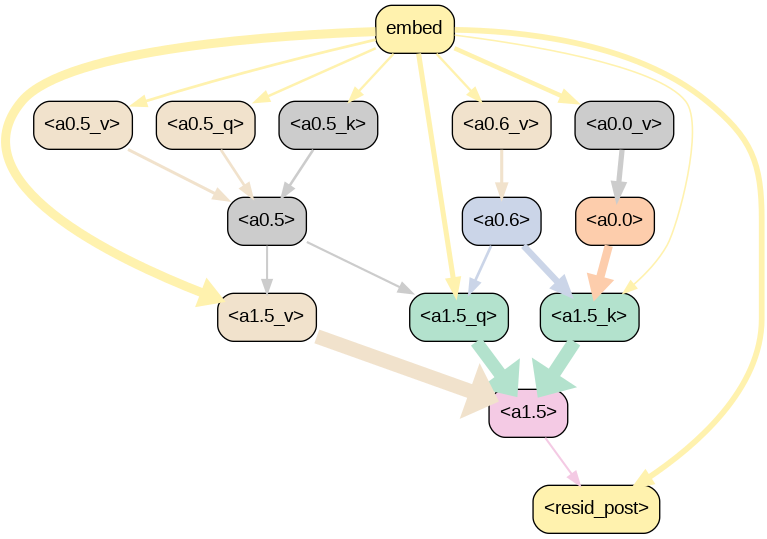

24 --------------------------------------------------
Edges remaining: 23
No edge 23
New metric: 5.938253402709961
We moved to  None
No edge 23
No edge 23
25 --------------------------------------------------
Edges remaining: 23


/content/Automatic-Circuit-Discovery/acdc/TLACDCExperiment.py:760: UserWarning: Finished iterating
  warnings.warn("Finished iterating")


In [28]:

import datetime
exp_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# for i in range(args.max_num_epochs):
#     exp.step(testing=False)

#     show(
#         exp.corr,
#         f"ims/img_new_{i+1}.png",
#         show_full_index=False,
#     )

#     if IN_COLAB or ipython is not None:
#         # so long as we're not running this as a script, show the image!
#         display(Image(f"ims/img_new_{i+1}.png"))

#     print(i, "-" * 50)
#     print(exp.count_no_edges())

#     if i == 0:
#         exp.save_edges("edges.pkl")

#     if exp.current_node is None or SINGLE_STEP:
#         show(
#             exp.corr,
#             f"ims/ACDC_img_{exp_time}.png",

#         )
#         break

# exp.save_edges("another_final_edges.pkl")

#DISPLAY GRAPH WHEN EDGE IS REMOVED
last_edge_count = exp.count_no_edges()

for i in range(args.max_num_epochs):
    exp.step(testing=False)

    current_edge_count = exp.count_no_edges()

    if current_edge_count < last_edge_count:
        print(f"Edge removed! New set: {current_edge_count}")

        fname = f"ims/img_pruned_{i+1}.png"
        show(exp.corr, fname=fname, show_full_index=False)

        if IN_COLAB or ipython is not None:
            display(Image(fname))

        last_edge_count = current_edge_count

    print(i, "-" * 50)
    print(f"Edges remaining: {current_edge_count}")

    if i == 0:
        exp.save_edges("edges.pkl")

    if exp.current_node is None or SINGLE_STEP:
        show(exp.corr, f"ims/ACDC_img_{exp_time}.png")
        break

if USING_WANDB:
    edges_fname = f"edges.pth"
    exp.save_edges(edges_fname)
    artifact = wandb.Artifact(edges_fname, type="dataset")
    artifact.add_file(edges_fname)
    wandb.log_artifact(artifact)
    os.remove(edges_fname)
    wandb.finish()


In [29]:
exp.save_subgraph(
    return_it=True,
)

OrderedDict([(('blocks.1.hook_resid_post',
               (None,),
               'blocks.1.attn.hook_result',
               (None, None, 5)),
              True),
             (('blocks.1.hook_resid_post',
               (None,),
               'blocks.0.hook_resid_pre',
               (None,)),
              True),
             (('blocks.1.attn.hook_result',
               (None, None, 5),
               'blocks.1.attn.hook_q',
               (None, None, 5)),
              True),
             (('blocks.1.attn.hook_result',
               (None, None, 5),
               'blocks.1.attn.hook_k',
               (None, None, 5)),
              True),
             (('blocks.1.attn.hook_result',
               (None, None, 5),
               'blocks.1.attn.hook_v',
               (None, None, 5)),
              True),
             (('blocks.1.attn.hook_q',
               (None, None, 5),
               'blocks.1.hook_q_input',
               (None, None, 5)),
              True),
        